# 05 — ShallowConvNet

Schirrmeister et al. 2017 — temporal conv → spatial conv → square → mean-pool → log. A near-direct learnt analogue of FBCSP and often the strongest deep MI baseline on small datasets.

Same CV folds, same non-augmented data as the EEGNet sweep so the comparison is fair.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from utils.data import load_xdf_epochs
from utils.eval import cv_score, save_result, RESULTS_DIR
from utils.plot import plot_confusion

torch.manual_seed(42); np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

X, y, classes = load_xdf_epochs('../visionpro-ml.xdf')
print('X:', X.shape, ' y:', y.shape, ' classes:', classes)

X: (90, 4, 625)  y: (90,)  classes: {0: 'left', 1: 'right', 2: 'both'}


In [2]:
class ShallowConvNet(nn.Module):
    """Schirrmeister et al. 2017 (arXiv:1703.05051), adapted for 4 channels."""
    def __init__(self, n_classes, n_channels, n_samples,
                 n_temporal=40, n_spatial=40, dropout=0.5):
        super().__init__()
        self.temporal = nn.Conv2d(1, n_temporal, (1, 25), bias=False)
        self.spatial  = nn.Conv2d(n_temporal, n_spatial, (n_channels, 1), bias=False)
        self.bn       = nn.BatchNorm2d(n_spatial)
        self.pool     = nn.AvgPool2d((1, 75), stride=(1, 15))
        self.dropout  = nn.Dropout(dropout)
        with torch.no_grad():
            flat = self._feat(torch.zeros(1, 1, n_channels, n_samples)).flatten(1).shape[1]
        self.classifier = nn.Linear(flat, n_classes)

    def _feat(self, x):
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.bn(x)
        x = x * x                   # square non-linearity
        x = self.pool(x)
        x = torch.log(x.clamp(min=1e-6))
        return x

    def forward(self, x):
        return self.classifier(self.dropout(self._feat(x)).flatten(1))

In [3]:
def train_one(X_tr, y_tr, X_val, y_val, epochs=150, lr=1e-3, batch=16):
    n_classes = int(max(y_tr.max(), y_val.max())) + 1
    n_ch, n_samp = X_tr.shape[1], X_tr.shape[2]
    model = ShallowConvNet(n_classes, n_ch, n_samp).to(DEVICE)

    counts = np.bincount(y_tr, minlength=n_classes).astype(np.float32)
    w = torch.from_numpy((1.0 / (counts + 1e-6)).astype(np.float32)); w /= w.sum()
    criterion = nn.CrossEntropyLoss(weight=w.to(DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)

    Xtr_t = torch.tensor(X_tr[:, None, :, :])
    ytr_t = torch.tensor(y_tr)
    Xv_t  = torch.tensor(X_val[:, None, :, :]).to(DEVICE)
    dl = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch, shuffle=True)

    best_state, best_acc = None, -1.0
    for _ in range(epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); criterion(model(xb), yb).backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            preds = model(Xv_t).argmax(1).cpu().numpy()
        acc = (preds == y_val).mean()
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        return model(Xv_t).argmax(1).cpu().numpy()

def fp(X_tr, y_tr, X_val, y_val):
    return train_one(X_tr, y_tr, X_val, y_val, epochs=150)

result = cv_score(fp, X, y, n_splits=5, seed=42)
print(f"acc={result['accuracy']:.3f} ± {result['accuracy_std']:.3f}  "
      f"f1={result['f1_macro']:.3f} ± {result['f1_macro_std']:.3f}")
print('per-class F1:', dict(zip(classes.values(),
                                  [round(v,3) for v in result['per_class_f1']])))

acc=0.511 ± 0.082  f1=0.486 ± 0.093
per-class F1: {'left': 0.418, 'right': 0.55, 'both': 0.49}


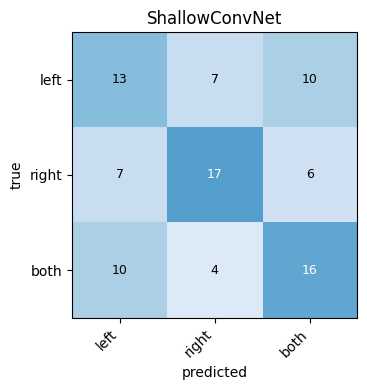

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
plot_confusion(np.array(result['confusion']), classes, ax=ax, title='ShallowConvNet')
plt.tight_layout(); plt.show()

In [5]:
save_result('05_shallow_convnet', result, classes)

final = ShallowConvNet(len(classes), X.shape[1], X.shape[2]).to(DEVICE)
counts = np.bincount(y, minlength=len(classes)).astype(np.float32)
w = torch.from_numpy((1.0 / (counts + 1e-6)).astype(np.float32)); w /= w.sum()
crit = nn.CrossEntropyLoss(weight=w.to(DEVICE))
opt = torch.optim.AdamW(final.parameters(), lr=1e-3, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200, eta_min=1e-5)
dl = DataLoader(TensorDataset(torch.tensor(X[:, None]), torch.tensor(y)),
                batch_size=16, shuffle=True)
final.train()
for _ in range(200):
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); crit(final(xb), yb).backward(); opt.step()
    sched.step()

out = RESULTS_DIR / '05_shallow_convnet.pt'
torch.save({
    'state_dict': {k: v.detach().cpu() for k, v in final.state_dict().items()},
    'classes': classes,
    'architecture': 'ShallowConvNet',
    'window_sec': 2.5,
    'channels': [0, 1, 3, 4],
}, out)
print('saved →', out)

saved → /Users/macuser/Downloads/EEG Classifier/notebooks/results/05_shallow_convnet.pt
